# Qrylov

## Setup

In [34]:
from typing import List, Tuple
import pickle as pkl

import matplotlib.pyplot as plt; plt.rcParams.update({"font.family": "serif"})
import numpy as np
import scipy as sp

import openfermion as of
from openfermionpyscf import run_pyscf

import numpy as np
import openfermion as of

import cirq
import qiskit
import qiskit.qasm2
import quimb.tensor as qtn

from tensor_network_common import pauli_sum_to_mpo

## Parameters

In [35]:
# Problem to use.
problem: str = "hchain"  # Options: "hchain", "hubbard", "product", "reactant"

# For Hubbard Hamiltonian.
xdim: int = 2
ydim: int = 3

# For Hydrogen chains.
natoms: int = 3  # Number of H atoms in the (linear) chain.

hamiltonian_threshold: float = 0.02 # Drop terms in the Hamiltonian with coefficients smaller than this threshold.

# Initial state parameters.
seed: int = 1
alpha: float = 10.0  # The initial state is |ground state> + |random state> / alpha.

# Krylov parameters.
subspace_dimension: int = 16  # The dimension of the Krylov subspace.
threshold: float = -np.inf  # 1e-4  # -np.inf  # -1e-4  # Set to -np.inf to disable thresholding.

# Simulation parameters.
max_mpo_bond: int = 128  # Maximum bond dimension for MPO's.
max_mps_bond: int = 256  # Maximum bond dimension for MPS's.

In [36]:
def fill_h_and_s_matrices(
    vectors: List[np.ndarray] | List[np.ndarray],
    mpo: qtn.MatrixProductOperator | np.ndarray,
    verbose: bool = False,
) -> Tuple[np.ndarray, np.ndarray]:
    tensor_algebra = isinstance(mpo, qtn.MatrixProductOperator)

    dim = len(vectors)
    h = np.zeros((dim, dim), dtype=np.complex128)
    s = np.zeros((dim, dim), dtype=np.complex128)

    for i in range(dim):
        for j in range(i, dim):
            if verbose:
                print(f"A_{i}{j}", end=" ")

            if tensor_algebra:
                hij = vectors[i].H @ mpo.apply(vectors[j])
            else:
                hij = vectors[i].conj().T @ mpo @ vectors[j]

            h[i, j] = hij
            if i != j:
                h[j, i] = np.conjugate(hij)

            if tensor_algebra:
                sij = vectors[i].H @ vectors[j]
            else:
                sij = vectors[i].conj().T @ vectors[j]
            s[i, j] = sij
            if i != j:
                s[j, i] = np.conjugate(sij)
    return h, s


# Based on https://quantum.cloud.ibm.com/docs/en/tutorials/krylov-quantum-diagonalization.
# and Algorithm 1.1 of https://arxiv.org/abs/2110.07492.
def solve_regularized_gen_eig(
    h: np.ndarray,
    s: np.ndarray,
    threshold: float = -np.inf,
) -> float:
    s_vals, s_vecs = sp.linalg.eigh(s)
    s_vecs = s_vecs.T
    good_vecs = np.array(
        [vec for val, vec in zip(s_vals, s_vecs) if val > threshold]
    )
    h_reg = good_vecs.conj() @ h @ good_vecs.T
    s_reg = good_vecs.conj() @ s @ good_vecs.T
    return sp.linalg.eigh(h_reg, s_reg)[0][0]

In [37]:
def unitary_h_and_s_variance(
    vectors: List[np.ndarray] | List[np.ndarray], ks: List[int], mpo: qtn.MatrixProductOperator | np.ndarray,
    subspace_dimension: int,
    h: np.ndarray, s: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
    """Compute the variance of the real and imaginary parts of the matrix elements
    H_ij and S_ij. When using the IBM measurement technique, the expectation values of
    X otimes H and Y otimes H give us the real and imaginary parts of the matrix
    elements. So to find the variance of H_ij, we would use 
    <(X otimes H)^2> = <(Y otimes H)^2> = <(I otimes H^2)>. 
    The value is
    <(I otimes H^2)> = 1/2 (<psi0| H^2 |psi0> + <psi0|U_{k-j}^dag H^2 U_{k-j}|psi0>).
    For the variance of S_ij, we would set H=I, giving
    <(I otimes I)> = 1/2 (<psi0|psi0> + <psi0|U_{k-j}^dag U_{k-j}|psi0>) = <psi0|psi0> = 1.
    
    Arguments:
    vectors - The vectors spanning the subspace.
    ks - The power of the unitary generating each vector, e.g. k=2 for U^2|psi_0>.
    Negative values mean backwards time evolution, i.e. powers of U^dagger.
    mpo - Hamiltonian operator.
    h - H matrix previously calculated.
    s - S matrix previously calculated.
    
    Returns:
    h_var - The re/im of h_var[i, j] is the variance of the re/im of H_ij.
    s_var - The re/im of s_var[i, j] is the variance of the re/im of S_ij."""

    tensor_algebra = isinstance(mpo, qtn.MatrixProductOperator)

    dim = len(vectors)
    h_var = np.zeros((subspace_dimension+1, subspace_dimension+1), dtype=np.complex128)
    s_var = np.zeros((subspace_dimension+1, subspace_dimension+1), dtype=np.complex128)

    # Find the reference state to get <psi0|H^2|psi0>.
    idx = ks.index(0)
    psi0 = vectors[idx]
    if tensor_algebra:
        psi0_h2_psi0 = psi0.H @ mpo.apply(mpo.apply(psi0))
    else:
        psi0_h2_psi0 = psi0.conj().T @ mpo @ mpo @ psi0
    
    for k in range(-subspace_dimension // 2, subspace_dimension // 2 + 1, 1):
        for j in range(-subspace_dimension // 2, subspace_dimension // 2 + 1, 1):
            # print(f"k={k} j={j}, k-j={k-j}")
            # Find a state with power k-j. Compute <psi0|U^dag_{k-j} H^2 U_{k-j}|psi0>.
            idx = ks.index(k - j)
            if tensor_algebra:
                psi0_u_h2_u_psi0 = vectors[idx].H @ mpo.apply(mpo.apply(vectors[idx]))
            else:
                psi0_u_h2_u_psi0 = vectors[idx].conj().T @ mpo @ mpo @ vectors[idx]
            exp_h_sq = 0.5 * (psi0_h2_psi0 + psi0_u_h2_u_psi0)
            var_re_h_kj = exp_h_sq - h[k, j].real ** 2
            var_im_h_kj = exp_h_sq - h[k, j].real ** 2
            h_var[k, j] = var_re_h_kj + 1.0j * var_im_h_kj
            var_re_s_kj = 1. - s[k, j].real ** 2
            var_im_s_kj = 1. - s[k, j].real ** 2
            h_var[k, j] = var_re_s_kj + 1.0j * var_im_s_kj

    return h_var, s_var

In [38]:
output_dictionary = {}

## Problem definition

In [39]:
if problem == "hchain":
    bond_distance = 1.0
    geometry = [("H", (0, 0, i * bond_distance)) for i in range(natoms)]
    molecule = of.MolecularData(geometry, basis="sto-3g", multiplicity=1, charge=natoms % 2)

    molecule = run_pyscf(molecule, run_scf=True, run_mp2=True, verbose=True)

    hamiltonian = of.get_fermion_operator(molecule.get_molecular_hamiltonian())
    hamiltonian = of.jordan_wigner(hamiltonian)

elif problem == "hubbard":
    hamiltonian = of.jordan_wigner(
        of.hamiltonians.fermi_hubbard(
            xdim,
            ydim,
            1.0,
            1.0,
            spinless=True
        )
    )

elif problem in ("product", "reactant"):
    data = np.load(f"./hamiltonians/po3_1w_{problem}_22o.npz")
    ecore = data["e_nuc"]
    h1 = np.array(data["h1"])
    h2 = np.array(data["h2"])
    nelectrons = data["nelectron"]

    h1_new, h2_new = of.chem.molecular_data.spinorb_from_spatial(h1, h2)
    h = of.InteractionOperator(ecore.item(), h1_new, h2_new)
    hamiltonian = of.get_fermion_operator(h)
    if hamiltonian_threshold is not None:
        hamiltonian.compress(hamiltonian_threshold)
    hamiltonian = of.jordan_wigner(hamiltonian)

else:
    raise ValueError(f"Unknown problem {problem}.")

Hartree-Fock energy for H3_sto-3g_singlet_1+ (2 electrons) is -1.1889970389622468.
MP2 energy for H3_sto-3g_singlet_1+ (2 electrons) is -1.2131306955585313.


In [40]:
if hamiltonian_threshold is not None:
    hamiltonian.compress(hamiltonian_threshold)

In [41]:
nqubits = of.utils.count_qubits(hamiltonian)
nterms = len(hamiltonian.terms)
print(f"Hamiltonian acts on {nqubits} qubit(s) and has {nterms} Pauli terms.")

Hamiltonian acts on 6 qubit(s) and has 54 Pauli terms.


## Exact energy

In [42]:
hamiltonian_cirq = of.qubit_operator_to_pauli_sum(hamiltonian)
mpo = pauli_sum_to_mpo(hamiltonian_cirq, cirq.LineQubit.range(nqubits), max_bond=max_mpo_bond, verbose=True)
mpo.show()

│4│16│26│16│4│m 54 / 54
●─<──<──<──<─<
│ │  │  │  │ │


/Users/benjamindalfavero/.venv/compare/lib/python3.13/site-packages/autoray/autoray.py:81: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/benjamindalfavero/.venv/compare/lib/python3.13/site-packages/autoray/autoray.py:81: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/benjamindalfavero/.venv/compare/lib/python3.13/site-packages/autoray/autoray.py:81: RuntimeWarning: invalid value encountered in matmul
  return func(*args, **kwargs)


In [43]:
dmrg = qtn.DMRG2(mpo, bond_dims=[2 ** (i + 1) for i in range(int(np.log2(max_mpo_bond)))])
dmrg.solve(verbosity=1)

energy_exact = np.real(dmrg.energy)
ground_state = dmrg.state
print("Exact energy:", energy_exact)
ground_state.show()

1, R, max_bond=(2/2), cutoff:1e-08


100%|###########################################| 5/5 [00:00<00:00, 1737.92it/s]

Energy: (-1.5179539174683898-1.377207809599712e-15j) ... not converged.
2, R, max_bond=(2/4), cutoff:1e-08



100%|###########################################| 5/5 [00:00<00:00, 1647.93it/s]

Energy: (-1.5452095284189378-1.330532906074211e-15j) ... not converged.
3, R, max_bond=(4/8), cutoff:1e-08


...

Energy: (-1.5483771453164556-1.1587952819525071e-15j) ... not converged.
4, R, max_bond=(6/16), cutoff:1e-08



100%|###########################################| 5/5 [00:00<00:00, 1331.61it/s]

Energy: (-1.5618170513793657-2.746934624209274e-15j) ... not converged.
5, R, max_bond=(7/32), cutoff:1e-08



100%|###########################################| 5/5 [00:00<00:00, 1465.82it/s]

Energy: (-1.5618170516201886-3.0505112325052153e-15j) ... converged!
Exact energy: -1.5618170516201886
 2 4 7 4 2 
>─>─>─>─>─●
│ │ │ │ │ │


In [44]:
output_dictionary["exact_energy"] = energy_exact

## Initial state

In [45]:
bvec = ground_state + qtn.MPS_rand_state(mpo.L, bond_dim=2, seed=seed) / alpha
bvec /= bvec.norm()
overlap = np.abs(bvec @ ground_state) ** 2
overlap

/Users/benjamindalfavero/.venv/compare/lib/python3.13/site-packages/autoray/autoray.py:81: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/benjamindalfavero/.venv/compare/lib/python3.13/site-packages/autoray/autoray.py:81: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/benjamindalfavero/.venv/compare/lib/python3.13/site-packages/autoray/autoray.py:81: RuntimeWarning: invalid value encountered in matmul
  return func(*args, **kwargs)


0.9534719008349127

### Unitary Krylov

In [46]:
# See Theorem 3.1 of https://arxiv.org/abs/2110.07492.
# dt = np.pi / (evals_exact[-1] - evals_exact[0])
dt = np.pi / mpo.norm()

if problem == "hchain":
    dt *= 5 * natoms  # Empirically found that larger dt works better for H chains.

dt

7.942794193623211

In [47]:
if nqubits <= 10:
    matrix = mpo.to_dense()
    vec = bvec.to_dense()

    all_vectors_u = [] # Ranges -d to d. Needed for variance.
    vectors_u = [] # Range -d/2 to d/2.
    ks = []
    for k in range(-subspace_dimension, subspace_dimension + 1, 1):
        ks.append(k)
        print(k)
        Uk = sp.sparse.linalg.expm(-1j * matrix * k * dt)  # TODO: Speedup with https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.expm_multiply.html.
        all_vectors_u.append(Uk @ vec)
        if (k <= 0 and abs(k) <= subspace_dimension // 2) or (k >= 0 and k <= subspace_dimension // 2):
            vectors_u.append(Uk @ vec)
        
        
    print(len(all_vectors_u), len(vectors_u))


    h, s = fill_h_and_s_matrices(vectors_u, matrix, verbose=True)
    output_dictionary["hs_u"] = (h, s)

    krylov_u_dvals = []
    krylov_u_evals = []
    for d in range(1, len(h)):
        try:
            krylov_energy = solve_regularized_gen_eig(h[:d, :d], s[:d, :d], threshold=threshold)
            print(d, krylov_energy)
            krylov_u_dvals.append(d)
            krylov_u_evals.append(krylov_energy)
        except np.linalg.LinAlgError:
            continue

h_var, s_var = unitary_h_and_s_variance(all_vectors_u, ks, matrix, subspace_dimension, h, s)

-16
-15
-14
-13
-12
-11
-10
-9
-8
-7
-6
-5
-4
-3
-2
-1
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
33 17
A_00 A_01 A_02 A_03 A_04 A_05 A_06 A_07 A_08 A_09 A_010 A_011 A_012 A_013 A_014 A_015 A_016 A_11 A_12 A_13 A_14 A_15 A_16 A_17 A_18 A_19 A_110 A_111 A_112 A_113 A_114 A_115 A_116 A_22 A_23 A_24 A_25 A_26 A_27 A_28 A_29 A_210 A_211 A_212 A_213 A_214 A_215 A_216 A_33 A_34 A_35 A_36 A_37 A_38 A_39 A_310 A_311 A_312 A_313 A_314 A_315 A_316 A_44 A_45 A_46 A_47 A_48 A_49 A_410 A_411 A_412 A_413 A_414 A_415 A_416 A_55 A_56 A_57 A_58 A_59 A_510 A_511 A_512 A_513 A_514 A_515 A_516 A_66 A_67 A_68 A_69 A_610 A_611 A_612 A_613 A_614 A_615 A_616 A_77 A_78 A_79 A_710 A_711 A_712 A_713 A_714 A_715 A_716 A_88 A_89 A_810 A_811 A_812 A_813 A_814 A_815 A_816 A_99 A_910 A_911 A_912 A_913 A_914 A_915 A_916 A_1010 A_1011 A_1012 A_1013 A_1014 A_1015 A_1016 A_1111 A_1112 A_1113 A_1114 A_1115 A_1116 A_1212 A_1213 A_1214 A_1215 A_1216 A_1313 A_1314 A_1315 A_1316 A_1414 A_1415 A_1416 A_1515 A_1516 A_1616 1 -1.55

/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/2049642181.py:12: RuntimeWarning: divide by zero encountered in matmul
  all_vectors_u.append(Uk @ vec)
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/2049642181.py:12: RuntimeWarning: overflow encountered in matmul
  all_vectors_u.append(Uk @ vec)
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/2049642181.py:12: RuntimeWarning: invalid value encountered in matmul
  all_vectors_u.append(Uk @ vec)
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/2049642181.py:14: RuntimeWarning: divide by zero encountered in matmul
  vectors_u.append(Uk @ vec)
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/2049642181.py:14: RuntimeWarning: overflow encountered in matmul
  vectors_u.append(Uk @ vec)
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/2049642181.py:14: RuntimeWarning: invalid value encountered in matmul
  vectors_u.append(Uk @ vec)
/var/folders/62/vp

In [48]:
print(h.shape)
print(h_var.shape)

(17, 17)
(17, 17)


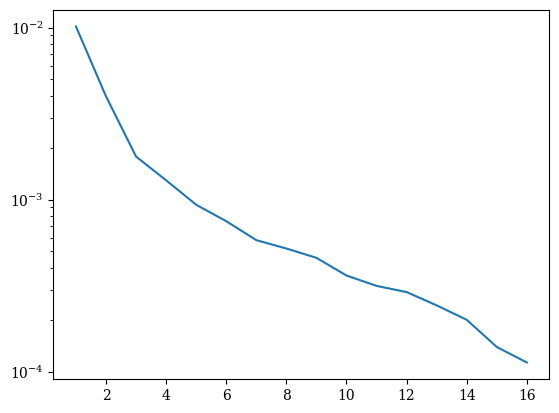

In [49]:
fig, ax = plt.subplots()
krylov_u_errors = np.abs(krylov_u_evals - energy_exact)
ax.plot(krylov_u_dvals, krylov_u_errors)
ax.set_yscale("log")

In [50]:
def perturb_h_s_with_noise(h: np.ndarray, s: np.ndarray, h_var: np.ndarray, s_var: np.ndarray, shots: int):
    assert h.shape == h_var.shape
    assert s.shape == s_var.shape

    noisy_h = np.zeros(h.shape).astype(complex)
    noisy_s = np.zeros(s.shape).astype(complex)

    for i in range(h.shape[0]):
        for j in range(h.shape[1]):
            if h_var[i, j].real < 0.:
                if abs(h_var[i, j].real) <= 1e-8:
                    h_var_real = 0.
                else:
                    raise ValueError(f"{h_var[i, j].real}")
            else:
                h_var_real = h_var[i, j].real
            if h_var[i, j].imag < 0.:
                if abs(h_var[i, j].imag) <= 1e-8:
                    h_var_imag = 0.
                else:
                    raise ValueError(f"{h_var[i, j].imag}")
            else:
                h_var_imag = h_var[i, j].imag
            std_re_hij = np.sqrt(h_var_real / shots)
            std_im_hij = np.sqrt(h_var_imag / shots)
            noise = np.random.normal(scale=std_re_hij) + 1.j * np.random.normal(scale=std_im_hij)
            assert not np.isnan(noise), f"{h_var[i, j]} {noise}"
            noisy_h[i, j] = h[i, j] + noise

            if s_var[i, j].real < 0.:
                if abs(s_var[i, j].real) <= 1e-8:
                    s_var_real = 0.
                else:
                    raise ValueError(f"{s_var[i, j].real}")
            else:
                s_var_real = s_var[i, j].real
            if s_var[i, j].imag < 0.:
                if abs(s_var[i, j].imag) <= 1e-8:
                    s_var_imag = 0.
                else:
                    raise ValueError(f"{s_var[i, j].imag}")
            else:
                s_var_imag = s_var[i, j].imag
            std_re_sij = np.sqrt(s_var_real / shots)
            std_im_sij = np.sqrt(s_var_imag / shots)
            noise = np.random.normal(scale=std_re_sij) + 1.j * np.random.normal(scale=std_im_sij)
            assert not np.isnan(noise), f"{s_var[i, j]} {s_var_real} {s_var_imag} {noise}"
            noisy_s[i, j] = s[i, j] + noise
    
    assert not np.any(np.isnan(noisy_h))
    assert not np.any(np.isnan(noisy_s))
    return noisy_h, noisy_s

In [51]:
def perturb_gaussian(h, s, std):
    noisy_h = h + np.random.normal(scale=std, size=h.shape)
    noisy_s = s + np.random.normal(scale=std, size=s.shape)
    return noisy_h, noisy_s

In [52]:
reps = 200
nshots = np.logspace(6, 11, num=10)
mean_errors = []
std_errors = []
for shots in nshots:
    print(f"shots={shots}")
    noisy_energies = []
    for _ in range(reps):
        noisy_h, noisy_s = perturb_h_s_with_noise(h, s, h_var, s_var, shots)
        # print(sp.linalg.norm(noisy_h - h))
        noisy_energy = solve_regularized_gen_eig(noisy_h, noisy_s)
        noisy_energies.append(noisy_energy)
    errs = np.abs(noisy_energies - energy_exact)
    mean_errors.append(np.mean(errs))
    std_errors.append(np.std(errs))

/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:48: RuntimeWarning: divide by zero encountered in matmul
  h_reg = good_vecs.conj() @ h @ good_vecs.T
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:48: RuntimeWarning: overflow encountered in matmul
  h_reg = good_vecs.conj() @ h @ good_vecs.T
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:48: RuntimeWarning: invalid value encountered in matmul
  h_reg = good_vecs.conj() @ h @ good_vecs.T
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:49: RuntimeWarning: divide by zero encountered in matmul
  s_reg = good_vecs.conj() @ s @ good_vecs.T
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:49: RuntimeWarning: overflow encountered in matmul
  s_reg = good_vecs.conj() @ s @ good_vecs.T
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:49: RuntimeWarning: invalid value e

shots=1000000.0
shots=3593813.6638046256
shots=12915496.650148828
shots=46415888.33612782
shots=166810053.72000557
shots=599484250.3189421
shots=2154434690.0318866
shots=7742636826.811277
shots=27825594022.07126
shots=100000000000.0


In [53]:
print(std_errors)

[7.549961306730554, 3.8334150864658763, 1.8861102069241416, 0.8493613335902018, 0.37958231576930435, 0.05587248889385368, 2.474764526727982e-05, 1.1372382050995541e-05, 5.235387429156452e-06, 3.016846697716657e-06]


In [55]:
final_noiseless_error = abs(krylov_u_evals[-1] - energy_exact)

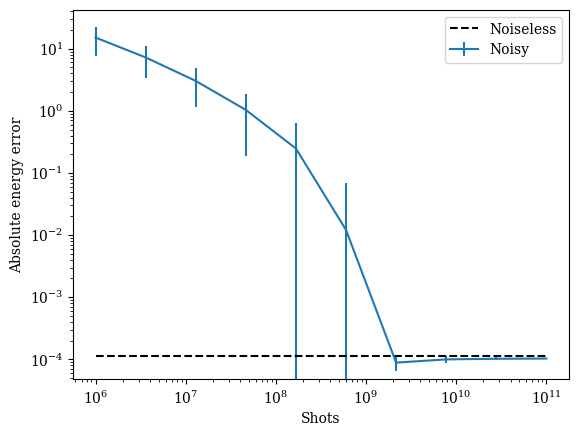

In [57]:
fig, ax = plt.subplots()
ax.errorbar(nshots, mean_errors, yerr=std_errors, label="Noisy")
ax.hlines(final_noiseless_error, np.min(nshots), np.max(nshots), linestyles="--", colors="k", label="Noiseless")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylabel("Absolute energy error")
ax.set_xlabel("Shots")
ax.legend()

## Repeat with Trotter circuits.

In [58]:
def cirq_pauli_sum_to_qiskit_pauli_op(pauli_sum: cirq.PauliSum) -> qiskit.quantum_info.SparsePauliOp:
    """Returns a qiskit.SparsePauliOp representation of the cirq.PauliSum."""
    cirq_pauli_to_str = {cirq.X: "X", cirq.Y: "Y", cirq.Z: "Z"}

    qubits = pauli_sum.qubits
    terms = []
    coeffs = []
    for term in pauli_sum:
        string = ""
        for qubit in qubits:
            if qubit not in term:
                string += "I"
            else:
                string += cirq_pauli_to_str[term[qubit]]
        terms.append(string)
        assert np.isclose(term.coefficient.imag, 0.0, atol=1e-7)
        coeffs.append(term.coefficient.real)
    return qiskit.quantum_info.SparsePauliOp(terms, coeffs)

In [59]:
hamiltonian_qiskit = cirq_pauli_sum_to_qiskit_pauli_op(hamiltonian_cirq)

In [60]:
ntrotter_values = [1, 2, 4, 8, 16, 32]
trotter_circuits = []
all_krylov_u_trotter_dvals = []
all_krylov_u_trotter_evals = []

ntrotter_hs_dict = {}
for ntrotter in ntrotter_values:
    print("Status: ntrotter =", ntrotter)
    trotter_operation = qiskit.circuit.library.PauliEvolutionGate(
        hamiltonian_qiskit,
        time=dt,
        synthesis=qiskit.synthesis.LieTrotter(reps=ntrotter)
    )
    trotter_circuit = qiskit.QuantumCircuit(nqubits)
    trotter_circuit.append(trotter_operation, trotter_circuit.qubits)
    trotter_circuit = qiskit.transpile(
        trotter_circuit, basis_gates=["u3", "cx"]
    )  # TODO: Compile to a target backend, e.g. IBM Fez.
    print("Trotter circuit gate counts:")
    print(trotter_circuit.count_ops())

    trotter_circuits.append(trotter_circuit)

    forward = trotter_circuit.copy()
    forward_qasm = qiskit.qasm2.dumps(forward)

    reverse = trotter_circuit.inverse().copy()
    reverse_qasm = qiskit.qasm2.dumps(reverse)

    forward_vectors = [bvec]

    for k in range(subspace_dimension // 2):
        print("Forward:", k)
        new = qtn.CircuitMPS.from_openqasm2_str(
            forward_qasm, psi0=forward_vectors[-1], progbar=False, max_bond=max_mps_bond,
        ).psi
        forward_vectors.append(new)
    
    reverse_vectors = [bvec]
    for k in range(subspace_dimension // 2):
        print("Reverse:", k)
        new = qtn.CircuitMPS.from_openqasm2_str(
            reverse_qasm, psi0=reverse_vectors[-1], progbar=False, max_bond=max_mps_bond,
        ).psi
        reverse_vectors.append(new)

    _ = reverse_vectors.pop(0)
    reverse_vectors = list(reversed(reverse_vectors))

    vectors_u_trotter = reverse_vectors + forward_vectors

    h, s = fill_h_and_s_matrices(vectors_u_trotter, mpo, verbose=True)
    ntrotter_hs_dict[ntrotter] = (h, s)

    krylov_u_trotter_evals = []
    krylov_u_trotter_dvals = []
    for d in range(1, len(h)):
        try:
            krylov_energy = solve_regularized_gen_eig(h[:d, :d], s[:d, :d], threshold=threshold)
            print(f"Krylov {d} energy:", krylov_energy)
            krylov_u_trotter_dvals.append(d)
            krylov_u_trotter_evals.append(krylov_energy)
        except np.linalg.LinAlgError:
            continue
    
    all_krylov_u_trotter_dvals.append(krylov_u_trotter_dvals)
    all_krylov_u_trotter_evals.append(krylov_u_trotter_evals)
    print("\n" * 10)

Status: ntrotter = 1
Trotter circuit gate counts:
OrderedDict({'cx': 223, 'u3': 208})
Forward: 0
Forward: 1
Forward: 2
Forward: 3
Forward: 4
Forward: 5


/Users/benjamindalfavero/.venv/compare/lib/python3.13/site-packages/autoray/autoray.py:81: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/benjamindalfavero/.venv/compare/lib/python3.13/site-packages/autoray/autoray.py:81: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/benjamindalfavero/.venv/compare/lib/python3.13/site-packages/autoray/autoray.py:81: RuntimeWarning: invalid value encountered in matmul
  return func(*args, **kwargs)


Forward: 6
Forward: 7
Reverse: 0
Reverse: 1
Reverse: 2
Reverse: 3
Reverse: 4
Reverse: 5
Reverse: 6
Reverse: 7
A_00 A_01 A_02 A_03 A_04 A_05 A_06 A_07 A_08 A_09 A_010 A_011 A_012 A_013 A_014 A_015 A_016 A_11 A_12 A_13 A_14 A_15 A_16 A_17 A_18 A_19 A_110 A_111 A_112 A_113 A_114 A_115 A_116 A_22 A_23 A_24 A_25 A_26 A_27 A_28 A_29 A_210 A_211 A_212 A_213 A_214 A_215 A_216 A_33 A_34 A_35 A_36 A_37 A_38 A_39 A_310 A_311 A_312 A_313 A_314 A_315 A_316 A_44 A_45 A_46 A_47 A_48 A_49 A_410 A_411 A_412 A_413 A_414 A_415 A_416 A_55 A_56 A_57 A_58 A_59 A_510 A_511 A_512 A_513 A_514 A_515 A_516 A_66 A_67 A_68 A_69 A_610 A_611 A_612 A_613 A_614 A_615 A_616 A_77 A_78 A_79 A_710 A_711 A_712 A_713 A_714 A_715 A_716 A_88 A_89 A_810 A_811 A_812 A_813 A_814 A_815 A_816 A_99 A_910 A_911 A_912 A_913 A_914 A_915 A_916 A_1010 A_1011 A_1012 A_1013 A_1014 A_1015 A_1016 A_1111 A_1112 A_1113 A_1114 A_1115 A_1116 A_1212 A_1213 A_1214 A_1215 A_1216 A_1313 A_1314 A_1315 A_1316 A_1414 A_1415 A_1416 A_1515 A_1516 A_1616

/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:48: RuntimeWarning: divide by zero encountered in matmul
  h_reg = good_vecs.conj() @ h @ good_vecs.T
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:48: RuntimeWarning: overflow encountered in matmul
  h_reg = good_vecs.conj() @ h @ good_vecs.T
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:48: RuntimeWarning: invalid value encountered in matmul
  h_reg = good_vecs.conj() @ h @ good_vecs.T
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:49: RuntimeWarning: divide by zero encountered in matmul
  s_reg = good_vecs.conj() @ s @ good_vecs.T
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:49: RuntimeWarning: overflow encountered in matmul
  s_reg = good_vecs.conj() @ s @ good_vecs.T
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:49: RuntimeWarning: invalid value e

Forward: 3
Forward: 4
Forward: 5
Forward: 6
Forward: 7
Reverse: 0
Reverse: 1
Reverse: 2
Reverse: 3
Reverse: 4
Reverse: 5
Reverse: 6
Reverse: 7
A_00 A_01 A_02 A_03 A_04 A_05 A_06 A_07 A_08 A_09 A_010 A_011 A_012 A_013 A_014 A_015 A_016 A_11 A_12 A_13 A_14 A_15 A_16 A_17 A_18 A_19 A_110 A_111 A_112 A_113 A_114 A_115 A_116 A_22 A_23 A_24 A_25 A_26 A_27 A_28 A_29 A_210 A_211 A_212 A_213 A_214 A_215 A_216 A_33 A_34 A_35 A_36 A_37 A_38 A_39 A_310 A_311 A_312 A_313 A_314 A_315 A_316 A_44 A_45 A_46 A_47 A_48 A_49 A_410 A_411 A_412 A_413 A_414 A_415 A_416 A_55 A_56 A_57 A_58 A_59 A_510 A_511 A_512 A_513 A_514 A_515 A_516 A_66 A_67 A_68 A_69 A_610 A_611 A_612 A_613 A_614 A_615 A_616 A_77 A_78 A_79 A_710 A_711 A_712 A_713 A_714 A_715 A_716 A_88 A_89 A_810 A_811 A_812 A_813 A_814 A_815 A_816 A_99 A_910 A_911 A_912 A_913 A_914 A_915 A_916 A_1010 A_1011 A_1012 A_1013 A_1014 A_1015 A_1016 A_1111 A_1112 A_1113 A_1114 A_1115 A_1116 A_1212 A_1213 A_1214 A_1215 A_1216 A_1313 A_1314 A_1315 A_1316 A_1414 A

In [68]:
final_energies = [kv[-1] for kv in all_krylov_u_trotter_evals]
noiseless_errors = np.abs(np.array(final_energies) - energy_exact)
print(noiseless_errors)

[0.00474813 0.00228723 0.00202953 0.00175146 0.00161072 0.00157966]


In [61]:
reps = 200
nshots = np.logspace(6, 11, num=10)
mean_errors = np.zeros((len(ntrotter_values), len(nshots)))
std_errors = np.zeros((len(ntrotter_values), len(nshots)))
for i, (ntrotter, (h, s)) in enumerate(ntrotter_hs_dict.items()):
    mean_errs = []
    std_errs = []
    for shots in nshots:
        print(f"shots={shots}")
        noisy_energies = []
        for _ in range(reps):
            noisy_h, noisy_s = perturb_h_s_with_noise(h, s, h_var, s_var, shots)
            # print(sp.linalg.norm(noisy_h - h))
            noisy_energy = solve_regularized_gen_eig(noisy_h, noisy_s)
            noisy_energies.append(noisy_energy)
        errs = np.abs(noisy_energies - energy_exact)
        mean_errs.append(np.mean(errs))
        std_errs.append(np.std(errs))
    mean_errors[i, :] = mean_errs 
    std_errors[i, :] = std_errs 

shots=1000000.0
shots=3593813.6638046256
shots=12915496.650148828
shots=46415888.33612782
shots=166810053.72000557
shots=599484250.3189421
shots=2154434690.0318866
shots=7742636826.811277
shots=27825594022.07126


/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:48: RuntimeWarning: divide by zero encountered in matmul
  h_reg = good_vecs.conj() @ h @ good_vecs.T
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:48: RuntimeWarning: overflow encountered in matmul
  h_reg = good_vecs.conj() @ h @ good_vecs.T
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:48: RuntimeWarning: invalid value encountered in matmul
  h_reg = good_vecs.conj() @ h @ good_vecs.T
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:49: RuntimeWarning: divide by zero encountered in matmul
  s_reg = good_vecs.conj() @ s @ good_vecs.T
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:49: RuntimeWarning: overflow encountered in matmul
  s_reg = good_vecs.conj() @ s @ good_vecs.T
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_2217/4144621074.py:49: RuntimeWarning: invalid value e

shots=100000000000.0
shots=1000000.0
shots=3593813.6638046256
shots=12915496.650148828
shots=46415888.33612782
shots=166810053.72000557
shots=599484250.3189421
shots=2154434690.0318866
shots=7742636826.811277
shots=27825594022.07126
shots=100000000000.0
shots=1000000.0
shots=3593813.6638046256
shots=12915496.650148828
shots=46415888.33612782
shots=166810053.72000557
shots=599484250.3189421
shots=2154434690.0318866
shots=7742636826.811277
shots=27825594022.07126
shots=100000000000.0
shots=1000000.0
shots=3593813.6638046256
shots=12915496.650148828
shots=46415888.33612782
shots=166810053.72000557
shots=599484250.3189421
shots=2154434690.0318866
shots=7742636826.811277
shots=27825594022.07126
shots=100000000000.0
shots=1000000.0
shots=3593813.6638046256
shots=12915496.650148828
shots=46415888.33612782
shots=166810053.72000557
shots=599484250.3189421
shots=2154434690.0318866
shots=7742636826.811277
shots=27825594022.07126
shots=100000000000.0
shots=1000000.0
shots=3593813.6638046256
shots=

Text(0, 0.5, 'Absolute energy error')

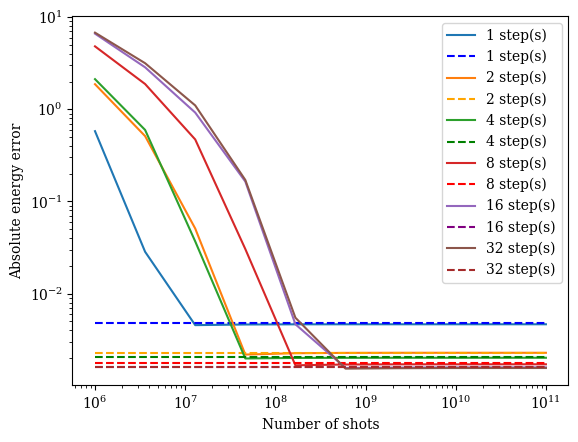

In [72]:
colors = ["b", "orange", "g", "r", "purple", "brown"]
fig, ax = plt.subplots()
for i, ntrotter in enumerate(ntrotter_values):
    ax.plot(nshots, mean_errors[i, :], label=f"{ntrotter} step(s)")
    ax.hlines(noiseless_errors[i], np.min(nshots), np.max(nshots), linestyles="--", colors=colors[i], label=f"{ntrotter} step(s)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_xlabel("Number of shots")
ax.set_ylabel("Absolute energy error")